In [2]:
%pip install -r utils/requirements.txt

  Using cached matplotlib-3.9.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached opencv_python-4.9.0.80-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached pillow-10.3.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.2 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached keras-3.13.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached tensorflow-2.17.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.2 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 72.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 MB 78.2 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 98.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 80.9 MB/s  0:00:0

In [3]:
!apt update && apt install -y libgl1 libglib2.0-0 libsm6 libxext6 libxrender-dev

Reading package lists... Done
E: List directory /var/lib/apt/lists/partial is missing. - Acquire (13: Permission denied)


In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from pathlib import Path

# Set up paths - Data is in utils/Data/Clean/
waldo_path = '/workspaces/Where-s-Wally/utils/Data/Clean/ClearedWaldos/'
heads_path = '/workspaces/Where-s-Wally/utils/Data/Clean/OnlyWaldoHeads/'

In [7]:
# Display examples of Only Wally
waldo_files = sorted([f for f in os.listdir(waldo_path) if f.endswith(('.jpg', '.png'))])
num_samples = min(5, len(waldo_files))

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for idx, file in enumerate(waldo_files[:num_samples]):
    img = mpimg.imread(os.path.join(waldo_path, file))
    if num_samples == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Display examples of Only Wally Heads
heads_files = sorted([f for f in os.listdir(heads_path) if f.endswith(('.jpg', '.png'))])
num_samples = min(5, len(heads_files))

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for idx, file in enumerate(heads_files[:num_samples]):
    img = mpimg.imread(os.path.join(heads_path, file))
    if num_samples == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/Where-s-Wally/utils/Data/Clean/ClearedWaldos/'

In [ ]:
import os
import sys

os.chdir('/workspaces/Where-s-Wally/utils')
sys.path.insert(0, '/workspaces/Where-s-Wally/utils')

try:
    from DataAugmentation import generating_waldos
    generating_waldos(use_background=True)
except Exception as e:
    print(f"Error type: {type(e).__name__}")
    print(f"Error message: {e}")
    import traceback
    traceback.print_exc()

Data path: /workspaces/Where-s-Wally/utils/Data
Found 6 head images and 31 background images
Will generate 372 total images


Generated 372 training images


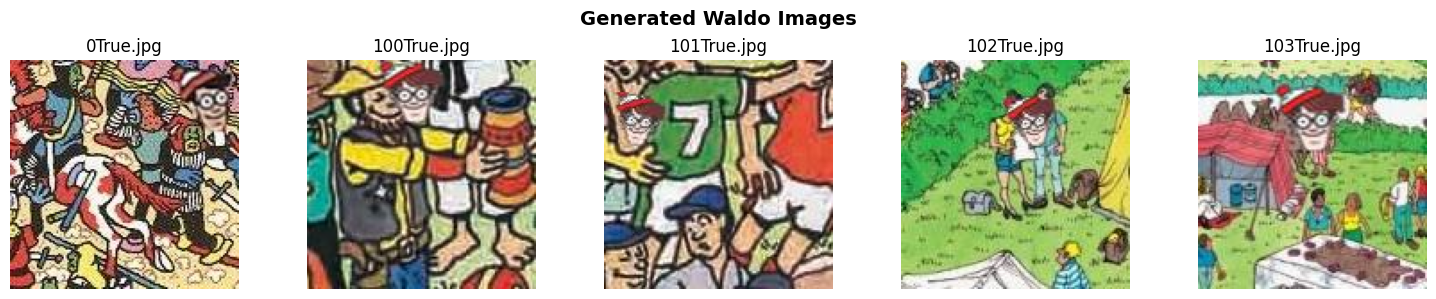

In [ ]:
# List the generated Waldo images from the DataAugmentation output
waldo_generated_files = sorted([f for f in os.listdir('/workspaces/Where-s-Wally/utils/Data/Waldo') if f.endswith('.jpg')])[:5]

# Display 5 images from the generated Waldo dataset
fig, axes = plt.subplots(1, len(waldo_generated_files), figsize=(15, 3))
fig.suptitle('Generated Waldo Images', fontsize=14, fontweight='bold')

for idx, file in enumerate(waldo_generated_files):
    img = mpimg.imread(os.path.join('/workspaces/Where-s-Wally/utils/Data/Waldo', file))
    if len(waldo_generated_files) == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from TrainModel import train_waldo_model

# Train from scratch on your generated images
model, X_test, Y_test, score = train_waldo_model(
    data_path='Data',
    epochs=15,
    test_size=0.10,
    save_path='Models/localize_trained.h5'
)

ImportError: libGL.so.1: cannot open shared object file: No such file or directory

In [ ]:
cv